In [9]:
import requests
from pathlib import Path
from IPython.display import Image, display
import json

In [10]:
root_url = "http://127.0.0.1:8000"

In [11]:
data_path = "../data/ASI0/2023/10/11/6300"

data_path = Path(data_path).resolve()

In [12]:
url = f"{root_url}/task"

response = requests.get(url)

print(response.status_code)
print(response.json())


200
{'status': '200'}


In [13]:
url = f"{root_url}/edit/create_img"

# Запрос с /docs
json_str = r'''
{
  "data_path": "путь к файлу",
  "files_list": [],
  "frame_number": 100,
  "flag_info": false,
  "general_title": "test",
  "cut": true,
  "percent_to_trim": 0.1,
  "save_folder": "buf",
  "figsize": [
    19.2,
    10.8
  ],
  "fit_format": "FitsInfo",
  "dark": false,
  "dark_file_name": "DARK",
  "zipped_file": true,
  "remove_single_pixels": false,
  "correct_matrix_path": null,
  "multiplication_on_correct_matrix": true,
  "rayleigh": false,
  "result_matrix_save_folder": null,
  "check_frame": 0,
  "auto_contrast": true,
  "auto_contrast_percentiles": [
    2,
    98
  ],
  "logfun": "string",
  "data_index": null,
  "file_name": "buf"
}
'''



In [14]:
# Изменение пути к файлу относительно запускаемого файла
new_json_str = json_str.replace(
    '"путь к файлу"',
    json.dumps(str(data_path))
)

Status: 200


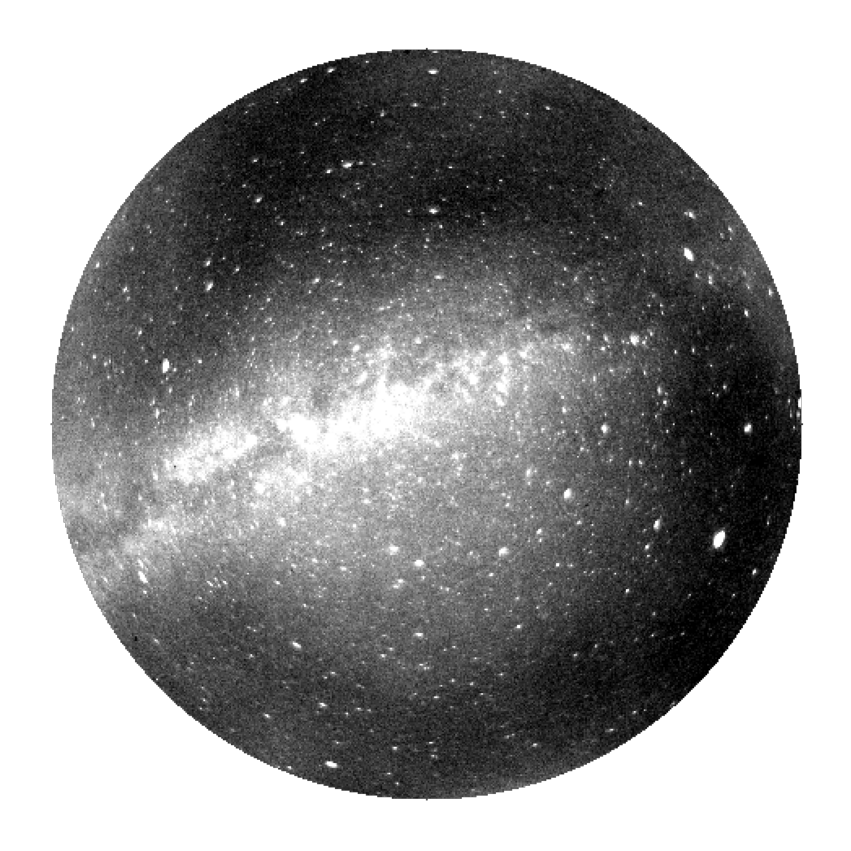

In [16]:
response = requests.post(
    url,
    data=new_json_str,
    headers={"Content-Type": "application/json"}
)

print("Status:", response.status_code)

display(Image(data=response.content))